# Visualizing Cycle Checking Strategies: Maze

Cycles are an issue with DFS and we need cycle checking.



# Code

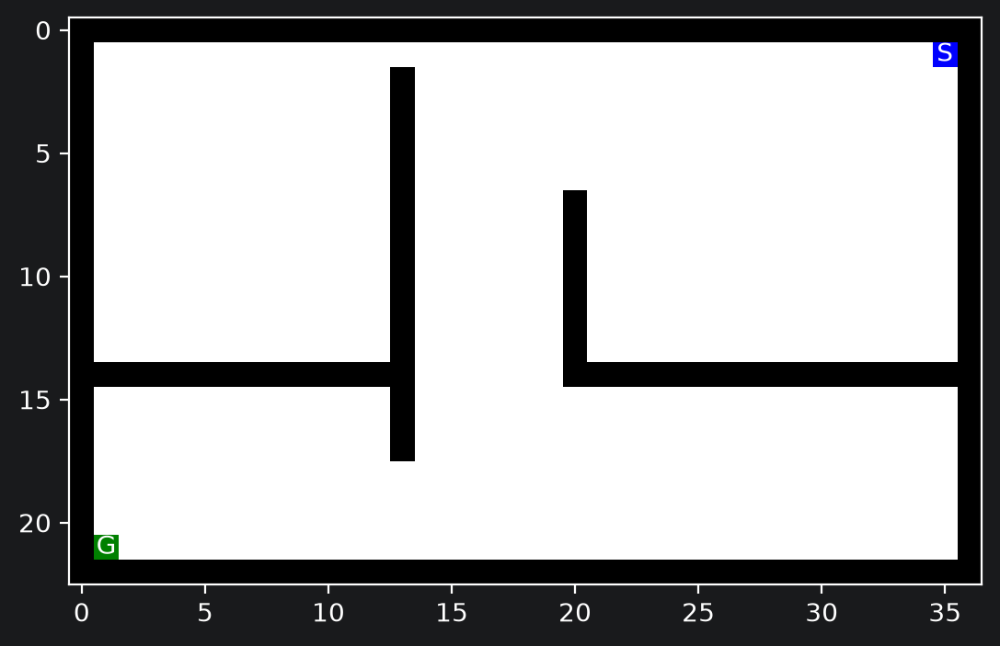

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import maze_helper as mh
from IPython.display import display

#f = open("small_maze.txt", "r")
#f = open("medium_maze.txt", "r")
#f = open("large_maze.txt", "r")    # this has only one solution!
f = open("open_maze.txt", "r")
#f = open("empty_maze.txt", "r")
#f = open("empty_maze_2.txt", "r")
#f = open("loops_maze.txt", "r")
#f = open("L_maze.txt", "r")

maze_str = f.read()
maze = mh.parse_maze(maze_str)

mh.show_maze(maze)


In [2]:
# tree_search_solution.py has my actual implementation (not published)
import tree_search_solution as ts

# order in which we add new states to the frontier
ts.set_order("NESW")
#ts.set_order(random=True)


Directions are checked in the order ['N', 'E', 'S', 'W']
Directions are checked in the order ['N', 'E', 'S', 'W']


## Phương án 1: Chỉ kiểm tra chu trình với các ô đã mở rộng (explored)

`frontier_option=1` — khi sinh trạng thái con, chỉ bỏ qua nếu ô đó **đã được mở rộng** (`explored`), tức là chỉ chặn quay ngược lại một ô đã đi qua.

* Mọi trạng thái con hợp lệ đều được đẩy vào frontier (stack).
* Ô đã nằm trong frontier nhưng chưa mở rộng vẫn có thể bị đẩy lại **nhiều lần** từ các nhánh khác nhau.

Hệ quả: DFS không lặp vô hạn, nhưng stack chứa nhiều nút trùng lặp nên số lần mở rộng và lượng bộ nhớ lớn hơn phương án 2.


In [3]:
# Phương án 1: chỉ kiểm tra chu trình với các ô đã mở rộng (explored).
%time result = ts.DFS(maze, vis=False, anim=True, max_tries=500, frontier_option=1)
print(f"Tries: {result['tries']}  Path: {len(result['path']) - 1}")

display(mh.animate_maze(result))

CPU times: total: 0 ns
Wall time: 18.1 ms
Tries: 344  Path: 54
Path length: 54
Reached squares: 0
Action sequence: ['W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'S', 'S', 'S']


Mê cung không còn ô trắng nào bị bỏ sót, nhưng vẫn còn các điểm cam ở trong frontier và các ô bị mở rộng lại nhiều lần (344 lần mở rộng cho 212 ô khác nhau).


## Phương án 2: Kiểm tra chu trình với cả ô đã mở rộng và ô đang nằm trong frontier

`frontier_option=2` — ngay khi sinh trạng thái con, nếu ô đó đã xuất hiện trong `seen` (tức là đã mở rộng **hoặc** đang nằm trong frontier) thì không thêm vào stack nữa.


In [4]:
# Phương án 2: kiểm tra chu trình với cả ô đã mở rộng và ô đang ở trong frontier.
%time result = ts.DFS(maze, vis=False, anim=True, max_tries=500, frontier_option=2)
print(f"Tries: {result['tries']}  Path: {len(result['path']) - 1}")

display(mh.animate_maze(result))

CPU times: total: 0 ns
Wall time: 17 ms
Tries: 212  Path: 54
Path length: 54
Reached squares: 0
Action sequence: ['W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'S', 'S', 'S']


Nhờ đó mỗi ô chỉ được sinh đúng một lần, frontier luôn sạch và DFS hội tụ nhanh nhất: **212** lần mở rộng cho đúng **212** ô khác nhau, giảm ~38% so với phương án 1.


## Phương án 3: Không kiểm tra chu trình

`check_cycle=False` — không kiểm tra gì cả, mọi trạng thái con đều được đẩy vào stack.


In [5]:
# Phương án 3: KHÔNG kiểm tra chu trình -> DFS đi lại vô hạn trong open maze.
%time result = ts.DFS(maze, check_cycle=False, vis=False, anim=True, max_tries=500)
print(f"Tries: {result['tries']}  Path: {'không tìm thấy' if result['path'] is None else len(result['path']) - 1}")

display(mh.animate_maze(result))

CPU times: total: 0 ns
Wall time: 25.3 ms
Tries: 500  Path: không tìm thấy
No solution found.


## Đánh giá & So sánh 3 Phương án Kiểm Tra Chu Trình (Cycle Checking) trong DFS

Kết quả đo trên mê cung **`open_maze.txt`**, thứ tự hướng `NESW`, `max_tries = 500`:

| Tiêu chí so sánh | Phương án 1 (`frontier_option=1`)<br>*Chỉ check ô đã mở rộng (Explored)* | Phương án 2 (`frontier_option=2`)<br>*Check cả Explored + Frontier* | Phương án 3 (`check_cycle=False`)<br>*Không kiểm tra chu trình* |
| :--- | :---: | :---: | :---: |
| **Tìm thấy đường đi?** | Có (dài **54** bước) | Có (dài **54** bước) | Không (đạt `max_tries`) |
| **Số lần mở rộng (`tries`)** | **344** | **212** (giảm ~38.4%) | **500** (hết ngân sách) |
| **Số ô khác nhau đã mở rộng** | **212** (132 lần mở rộng lại) | **212** (mỗi ô đúng 1 lần) | **48** (kẹt trong vòng lặp cục bộ) |
| **Kích thước frontier tối đa** | 155 | 89 | 771 (phình theo độ sâu stack) |
| **Mức độ loại bỏ lặp trạng thái** | Trung bình (loại muộn, khi sinh node con) | **Tốt nhất** (loại ngay khi sinh node con) | Không loại bỏ |

---

### Nhận xét chi tiết:

1. **Phương án 1 (`frontier_option=1`):**
   - **Cơ chế:** khi sinh node con, chỉ bỏ qua nếu ô đó đã nằm trong `explored`.
   - **Ưu/Nhược điểm:** chặn được việc quay ngược trên cùng một nhánh, nhưng ô đang nằm trong frontier vẫn bị sinh lại từ nhiều nhánh khác → **344** lần mở rộng cho **212** ô, stack phình to (peak **155**).

2. **Phương án 2 (`frontier_option=2`):**
   - **Cơ chế:** ngay khi sinh node con, kiểm tra tập `seen` = *đã mở rộng ∪ đang ở trong frontier*. Trùng thì không thêm vào stack.
   - **Ưu/Nhược điểm:** **tốt nhất trong 3 phương án**. Mỗi ô chỉ mở rộng đúng một lần nên `tries` = số ô = **212**, frontier nhỏ nhất (peak **89**), hội tụ nhanh nhất.

3. **Phương án 3 (`check_cycle=False`):**
   - **Cơ chế:** đẩy mọi node con vào stack, không kiểm tra lặp.
   - **Hậu quả:** trong mê cung có chu trình, DFS đi lại giữa các ô kề nhau ($A \rightarrow B \rightarrow A \rightarrow B \dots$), stack phình liên tục (peak **771**), chỉ kẹt trong **48** ô và không bao giờ tới được $G$ — đây chính là lý do DFS bắt buộc phải có cycle checking.
